# TCC Experimento 2: Reconhecimento de Placas (UFPR-ALPR)

**Objetivo**: Avaliar a precisão do pipeline ALPR completo (Detecção de Veículo + Detecção de Placa + OCR).

---
**Métricas**: IoU (Placa), CER (OCR), Exact Match (Acurácia).

## 1. Configuração e Ambiente

In [1]:
import sys, cv2, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display
import torch


BASE_DIR = Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
%matplotlib inline

UFPR_ROOT      = BASE_DIR / "data" / "UFPR-ALPR"
RESULTS_DIR    = BASE_DIR / "data" / "processado" / "resultados"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# LIMITAÇÃO DE EXECUÇÃO: Ajuste aqui para testes rápidos
LIMIT = 1500  # Defina como None para rodar o dataset completo (1500 imagens)

print(f"UFPR-ALPR dataset: {'Encontrado' if UFPR_ROOT.exists() else 'NÃO ENCONTRADO'}")
print(f"Dispositivo GPU disponível: {torch.cuda.is_available()}")

UFPR-ALPR dataset: Encontrado
Dispositivo GPU disponível: False


## 2. Análise e Visualização do Dataset UFPR-ALPR

In [2]:
# =============================================================================
# CÓDIGO AUXILIAR (DETECTORES, OCR, PARSER, AVALIAÇÃO E BENCHMARK) - CONSOLIDADO
# =============================================================================
import torch
import cv2
import numpy as np
import pandas as pd
import time
import random
import re
import easyocr
import pytesseract
from pathlib import Path
from abc import ABC, abstractmethod
from ultralytics import YOLO
from torchvision.models.detection import fasterrcnn_resnet50_fpn, ssdlite320_mobilenet_v3_large
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights, SSDLite320_MobileNet_V3_Large_Weights
from tqdm import tqdm

# --- PARSER UFPR-ALPR ---
from pathlib import Path


def parse_annotation(txt_path: Path) -> dict:
    """
    Lê um arquivo .txt do UFPR-ALPR e retorna um dicionário com:
        - plate_text   : str   — ex: 'AQY6388'
        - vehicle_bbox : list  — [x1, y1, x2, y2]
        - plate_bbox   : list  — [x1, y1, x2, y2] (bounding rect dos 4 cantos)
        - plate_corners: list  — [[x,y], [x,y], [x,y], [x,y]]
    Retorna None se o arquivo não puder ser lido.
    """
    try:
        data = {}
        with open(txt_path, 'r', encoding='utf-8') as f:
            lines = f.readlines()

        for line in lines:
            line = line.strip()

            # Posição do veículo: x y w h
            if line.startswith('position_vehicle:'):
                parts = line.split(':')[1].strip().split()
                x, y, w, h = int(parts[0]), int(parts[1]), int(parts[2]), int(parts[3])
                data['vehicle_bbox'] = [x, y, x + w, y + h]

            # Texto da placa
            elif line.startswith('plate:'):
                data['plate_text'] = line.split(':')[1].strip()

            # Cantos da placa: x1,y1 x2,y2 x3,y3 x4,y4
            elif line.startswith('corners:'):
                corners_str = line.split(':')[1].strip().split()
                corners = []
                for c in corners_str:
                    cx, cy = c.split(',')
                    corners.append([int(cx), int(cy)])
                data['plate_corners'] = corners

                # Calcula bounding box retangular a partir dos 4 cantos
                xs = [p[0] for p in corners]
                ys = [p[1] for p in corners]
                data['plate_bbox'] = [min(xs), min(ys), max(xs), max(ys)]

        return data if 'plate_text' in data else None

    except Exception as e:
        print(f"Erro ao parsear {txt_path}: {e}")
        return None


def load_dataset_split(dataset_root: Path, split: str = 'testing', limit: int = None) -> list:
    """
    Carrega todos os pares (imagem, anotação) de um split do UFPR-ALPR.

    Args:
        dataset_root: caminho para a pasta 'UFPR-ALPR dataset'
        split: 'testing', 'training' ou 'validation'
        limit: número máximo de amostras a carregar (None = todas)

    Returns:
        Lista de dicts com chaves: 'image_path', 'annotation'
    """
    split_path = dataset_root / split
    samples = []

    # O dataset é organizado em track0001/, track0002/, etc.
    for track_dir in sorted(split_path.iterdir()):
        if not track_dir.is_dir():
            continue
        for img_path in sorted(track_dir.glob('*.png')):
            txt_path = img_path.with_suffix('.txt')
            if not txt_path.exists():
                continue
            annotation = parse_annotation(txt_path)
            if annotation:
                samples.append({
                    'image_path': img_path,
                    'annotation': annotation
                })
            if limit and len(samples) >= limit:
                return samples

    return samples

# --- DETECTORES DE VEÍCULOS E PLACAS ---
class BaseDetector(ABC):
    @abstractmethod
    def detect(self, frame):
        """Retorna lista de detecções: [{'bbox': [x1, y1, x2, y2], 'conf': 0.9, 'class': 'car'}]"""
        pass

class YOLODetector(BaseDetector):
    def __init__(self, model_path='yolov8n.pt'):
        self.model = YOLO(model_path)
        self.model_name = "YOLOv8"
        
    def detect(self, frame):
        results = self.model(frame, verbose=False)[0]
        detections = []
        for box in results.boxes:
            detections.append({
                'bbox': box.xyxy[0].tolist(),
                'conf': float(box.conf),
                'class': self.model.names[int(box.cls)]
            })
        return detections

class TorchvisionDetector(BaseDetector):
    def __init__(self, model_type='faster_rcnn', confidence_threshold=0.5):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.threshold = confidence_threshold
        self.model_name = "Faster R-CNN" if model_type == 'faster_rcnn' else "SSD"
        
        if model_type == 'faster_rcnn':
            weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
            self.model = fasterrcnn_resnet50_fpn(weights=weights).to(self.device)
            self.classes = weights.meta["categories"]
        else: # SSD
            weights = SSDLite320_MobileNet_V3_Large_Weights.DEFAULT
            self.model = ssdlite320_mobilenet_v3_large(weights=weights).to(self.device)
            self.classes = weights.meta["categories"]
            
        self.model.eval()

    def detect(self, frame):
        # Preprocess
        img_tensor = torch.from_numpy(frame).permute(2, 0, 1).float().div(255).unsqueeze(0).to(self.device)
        
        with torch.no_grad():
            prediction = self.model(img_tensor)[0]
        
        detections = []
        for i in range(len(prediction['boxes'])):
            score = float(prediction['scores'][i])
            if score > self.threshold:
                detections.append({
                    'bbox': prediction['boxes'][i].tolist(),
                    'conf': score,
                    'class': self.classes[int(prediction['labels'][i])]
                })
        return detections

class PlateDetector(BaseDetector):
    def __init__(self):
        print("Carregando modelo YOLOv8 para detecção de placas...")
        try:
            from huggingface_hub import hf_hub_download
            # Automatically downloads the model from Hugging Face Hub to your local cache
            model_path = hf_hub_download(repo_id="Koushim/yolov8-license-plate-detection", filename="best.pt")
            self.model = YOLO(model_path)
            self.has_model = True
        except Exception as e:
            print(f"Erro ao carregar o modelo de placas: {e}")
            self.has_model = False
        self.model_name = "YOLOv8 Plate Detector"
        
    def detect(self, frame):
        if self.has_model:
            results = self.model(frame, verbose=False)[0]
            detections = []
            for box in results.boxes:
                detections.append({
                    'bbox': box.xyxy[0].tolist(),
                    'conf': float(box.conf),
                    'class': 'plate'
                })
            return detections
        return []

       
# --- OCR ENGINE ---

# ---------------------------------------------------------------------------
# Mapeamentos de correção por posição para placas brasileiras
#
# Formato antigo:  L L L N N N N   (ex: MLS5511)
# Formato Mercosul: L L L N L N N  (ex: ABC1D23)
#
# O OCR frequentemente troca:
#   letras por números: O↔0, I↔1, S↔5, B↔8, Z↔2, G↔6, Q↔0
#   números por letras: 0↔O, 1↔I, 5↔S, 8↔B, 2↔Z, 6↔G
# ---------------------------------------------------------------------------

# Caracteres que são letras mas parecem números
_NUM_TO_LETTER = str.maketrans('0158268479', 'OISBZGAHQ?')  # só se position for letra
# Caracteres que são números mas parecem letras
_LETTER_TO_NUM = str.maketrans('OISBZGAHQ', '015826649')   # só se position for dígito


def _fix_char(ch: str, expect_letter: bool) -> str:
    """Corrige um caractere OCR com base no tipo esperado na posição."""
    ch = ch.upper()
    if expect_letter:
        return ch.translate(_NUM_TO_LETTER)
    else:
        return ch.translate(_LETTER_TO_NUM)


def _is_mercosul(raw: str) -> bool:
    """Heurística para detectar se a placa está no formato Mercosul (AAA0A00)."""
    if len(raw) != 7:
        return False
    # Mercosul: posição 4 (índice 3) é número, posição 5 (índice 4) é letra
    # Antigo:   posições 4-7 (índices 3-6) são todos números
    return raw[4].isalpha() if raw[4].isascii() else False


def _apply_plate_mask(raw: str) -> str:
    """
    Aplica máscara de posição para corrigir confusões letra/número do OCR.

    Formato antigo:   L L L N N N N  (posições 0,1,2 = letra; 3,4,5,6 = dígito)
    Formato Mercosul: L L L N L N N  (posições 0,1,2 = letra; 3 = dígito;
                                       4 = letra; 5,6 = dígito)
    """
    if len(raw) < 7:
        return raw  # Muito curto — não tenta corrigir

    mercosul = _is_mercosul(raw)

    if mercosul:
        mask = [True, True, True, False, True, False, False]  # True = espera letra
    else:
        mask = [True, True, True, False, False, False, False]

    corrected = []
    for i, ch in enumerate(raw[:7]):
        if i < len(mask):
            corrected.append(_fix_char(ch, expect_letter=mask[i]))
        else:
            corrected.append(ch)

    return ''.join(corrected)


class OCREngine:
    def __init__(self, engine_type='easyocr'):
        self.engine_type = engine_type
        if engine_type == 'easyocr':
            # Português + inglês; GPU se disponível
            self.reader = easyocr.Reader(['pt', 'en'], gpu=True)

    # ------------------------------------------------------------------
    # Limpeza de texto bruto
    # ------------------------------------------------------------------
    def clean_text(self, text: str) -> str:
        """Remove tudo que não é letra ou dígito e converte para maiúsculo."""
        return re.sub(r'[^A-Z0-9]', '', text.upper())

    # ------------------------------------------------------------------
    # Pré-processamento da imagem da placa
    # ------------------------------------------------------------------
    def preprocess_plate(self, plate_crop: np.ndarray) -> np.ndarray:
        """
        Pipeline de pré-processamento otimizado para placas brasileiras.

        1. Upscaling 3× (melhora resolução para o OCR)
        2. Conversão para cinza
        3. CLAHE (equalização adaptativa de histograma — melhora contraste)
        4. Denoising leve (preserva bordas de caracteres)
        5. Threshold de Otsu (binarização global — mais estável que o adaptativo
           para placas com fundo uniforme)
        """
        h, w = plate_crop.shape[:2]
        # 1. Upscaling
        plate = cv2.resize(plate_crop, (w * 3, h * 3), interpolation=cv2.INTER_CUBIC)

        # 2. Cinza
        gray = cv2.cvtColor(plate, cv2.COLOR_BGR2GRAY)

        # 3. CLAHE — melhora contraste local sem destruir bordas finas
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
        gray = clahe.apply(gray)

        # 4. Denoising leve
        gray = cv2.fastNlMeansDenoising(gray, h=10, templateWindowSize=7, searchWindowSize=21)

        # 5. Threshold de Otsu
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        return binary

    # ------------------------------------------------------------------
    # Leitura da placa
    # ------------------------------------------------------------------
    def read_plate(self, plate_crop: np.ndarray) -> str:
        """
        Lê o texto de uma imagem de placa recortada.

        Etapas:
          1. Pré-processamento da imagem
          2. OCR (EasyOCR ou Tesseract)
          3. Limpeza do texto bruto
          4. Correção posicional letra/número (máscara de placa brasileira)
        """
        if plate_crop is None or plate_crop.size == 0:
            return ""

        processed = self.preprocess_plate(plate_crop)

        raw = ""
        if self.engine_type == 'easyocr':
            results = self.reader.readtext(processed)
            if results:
                # Pega a leitura com maior confiança
                raw = max(results, key=lambda x: x[2])[1]
        else:
            config = (
                '--psm 7 '
                '-c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
            )
            raw = pytesseract.image_to_string(processed, config=config)

        cleaned = self.clean_text(raw)

        # Aplica correção posicional se o texto tiver comprimento de placa válido (7)
        if len(cleaned) == 7:
            cleaned = _apply_plate_mask(cleaned)

        return cleaned

# --- AVALIAÇÃO (IoU, CER) ---

def compute_iou(box_a: list, box_b: list) -> float:
    """
    Calcula o IoU entre duas bounding boxes no formato [x1, y1, x2, y2].

    IoU = Área de Interseção / Área de União

    Retorna um valor entre 0.0 (sem sobreposição) e 1.0 (sobreposição perfeita).
    """
    # Interseção
    x1 = max(box_a[0], box_b[0])
    y1 = max(box_a[1], box_b[1])
    x2 = min(box_a[2], box_b[2])
    y2 = min(box_a[3], box_b[3])

    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    inter_area = inter_w * inter_h

    if inter_area == 0:
        return 0.0

    # Área de cada caixa
    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])

    union_area = area_a + area_b - inter_area
    return inter_area / union_area if union_area > 0 else 0.0


def compute_cer(predicted: str, ground_truth: str) -> float:
    """
    Calcula o CER (Character Error Rate) entre dois textos.

    CER = (Substituições + Inserções + Deleções) / len(ground_truth)

    Baseado na distância de edição de Levenshtein.
    Retorna 0.0 para acerto perfeito, 1.0 para erro total.
    """
    pred = predicted.upper().replace(' ', '') if predicted else ''
    gt   = ground_truth.upper().replace(' ', '') if ground_truth else ''

    if not gt:
        return 0.0 if not pred else 1.0

    # Matriz de Levenshtein
    n, m = len(gt), len(pred)
    dp = list(range(m + 1))

    for i in range(1, n + 1):
        prev = dp[:]
        dp[0] = i
        for j in range(1, m + 1):
            if gt[i - 1] == pred[j - 1]:
                dp[j] = prev[j - 1]
            else:
                dp[j] = 1 + min(prev[j], dp[j - 1], prev[j - 1])

    return min(dp[m] / n, 1.0)


def is_exact_match(predicted: str, ground_truth: str) -> bool:
    """Retorna True se a placa foi lida exatamente correta (ignorando maiúsculas)."""
    pred = predicted.upper().replace(' ', '').replace('-', '') if predicted else ''
    gt   = ground_truth.upper().replace(' ', '').replace('-', '') if ground_truth else ''
    return pred == gt


def evaluate_detection(predicted_bbox: list, ground_truth_bbox: list,
                        predicted_text: str, ground_truth_text: str) -> dict:
    """
    Avalia uma única detecção de placa contra o ground truth.

    Retorna dict com:
        - iou         : float (0-1)
        - cer         : float (0-1, menor é melhor)
        - exact_match : bool
        - plate_found : bool (IoU > 0.3)
    """
    iou = compute_iou(predicted_bbox, ground_truth_bbox) if predicted_bbox else 0.0
    cer = compute_cer(predicted_text, ground_truth_text)
    match = is_exact_match(predicted_text, ground_truth_text)

    return {
        'iou': iou,
        'cer': cer,
        'exact_match': match,
        'plate_found': iou > 0.3,  # Limiar padrão para "detectou corretamente"
    }

# --- RUN BENCHMARK ALPR ---
def run_benchmark(split: str = 'testing', limit: int = None):
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

    print("=" * 60)
    print("  BENCHMARK ALPR — UFPR-ALPR Dataset (Ground Truth Real)")
    print("=" * 60)

    # --- Carrega amostras do split ---
    print(f"\nCarregando split '{split}'...")
    samples = load_dataset_split(UFPR_ROOT, split=split, limit=limit)
    print(f"  Total de amostras carregadas: {len(samples)}")

    # --- Detectores de veículo ---
    models_config = [
        ('YOLOv8',       lambda: YOLODetector('yolov8n.pt')),
        ('SSD',          lambda: TorchvisionDetector(model_type='ssd')),
        ('Faster R-CNN', lambda: TorchvisionDetector(model_type='faster_rcnn')),
    ]

    # Tenta inicializar cada modelo, pula se falhar
    vehicle_detectors = []
    for name, factory in models_config:
        try:
            print(f"  Carregando {name}...", end=' ')
            det = factory()
            vehicle_detectors.append((name, det))
            print("OK")
        except Exception as e:
            print(f"FALHOU ({type(e).__name__}). Pulando.")

    if not vehicle_detectors:
        print("Nenhum detector carregou com sucesso. Abortando.")
        return None

    # --- Detector de placa (único, compartilhado) ---
    plate_detector = PlateDetector()

    # --- OCR ---
    ocr = OCREngine(engine_type='easyocr')

    all_results = []

    for det_name, vehicle_det in vehicle_detectors:
        print(f"\n>>> Testando: {det_name}")

        for sample in tqdm(samples, desc=det_name):
            img_path   = sample['image_path']
            annotation = sample['annotation']
            gt_text    = annotation['plate_text']
            gt_bbox    = annotation['plate_bbox']       # ground truth da placa
            gt_veh     = annotation['vehicle_bbox']     # ground truth do veículo

            img = cv2.imread(str(img_path))
            if img is None:
                continue

            h_img, w_img = img.shape[:2]

            # --- Estágio 1: Usa o detector real para encontrar o veículo ---
            vehicle_detections = vehicle_det.detect(img)
            vehicles = [d for d in vehicle_detections
                        if d['class'] in ['car', 'truck', 'bus', 'motorcycle']]

            if vehicles:
                # Pega o maior veículo detectado
                v = max(vehicles, key=lambda d: (d['bbox'][2]-d['bbox'][0]) * (d['bbox'][3]-d['bbox'][1]))
                x1, y1, x2, y2 = map(int, v['bbox'])
                # Clipa para dentro da imagem
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(w_img, x2), min(h_img, y2)
                vehicle_crop = img[y1:y2, x1:x2]
                # Ajusta gt_bbox para o sistema de coordenadas do recorte
                gt_bbox_crop = [
                    gt_bbox[0] - x1, gt_bbox[1] - y1,
                    gt_bbox[2] - x1, gt_bbox[3] - y1,
                ]
            else:
                # Fallback: usa veículo do ground truth se o detector falhar
                x1, y1 = max(0, gt_veh[0]), max(0, gt_veh[1])
                x2, y2 = min(w_img, gt_veh[2]), min(h_img, gt_veh[3])
                vehicle_crop = img[y1:y2, x1:x2]
                gt_bbox_crop = [
                    gt_bbox[0] - x1, gt_bbox[1] - y1,
                    gt_bbox[2] - x1, gt_bbox[3] - y1,
                ]

            if vehicle_crop.size == 0:
                continue

            # --- Estágio 2: Detecta a placa dentro do recorte ---
            plate_detections = plate_detector.detect(vehicle_crop)

            if plate_detections:
                best_plate = max(plate_detections, key=lambda p: p['conf'])
                pred_bbox  = best_plate['bbox']
                px1, py1, px2, py2 = map(int, pred_bbox)
                px1, py1 = max(0, px1), max(0, py1)
                plate_crop = vehicle_crop[py1:py2, px1:px2]
            else:
                # Fallback: usa bbox GT da placa para isolar contribuição do OCR
                pred_bbox  = None
                gx1, gy1, gx2, gy2 = [max(0, int(c)) for c in gt_bbox_crop]
                plate_crop = vehicle_crop[gy1:gy2, gx1:gx2]

            # --- Estágio 3: OCR ---
            pred_text = ''
            if plate_crop is not None and plate_crop.size > 0:
                pred_text = ocr.read_plate(plate_crop) or ''

            # --- Avaliação ---
            metrics = evaluate_detection(pred_bbox, gt_bbox_crop, pred_text, gt_text)

            all_results.append({
                'model':         det_name,
                'track':         img_path.parent.name,   # ex: track0091
                'image':         img_path.name,
                'gt_plate':      gt_text,
                'pred_plate':    pred_text,
                'vehicle_found': len(vehicles) > 0,
                'iou':           round(metrics['iou'], 4),
                'cer':           round(metrics['cer'], 4),
                'exact_match':   metrics['exact_match'],
                'plate_found':   metrics['plate_found'],
            })

    # --- Salva CSV ---
    df = pd.DataFrame(all_results)
    csv_path = RESULTS_DIR / 'alpr_benchmark.csv'
    df.to_csv(csv_path, index=False)
    print(f"\nResultados salvos em: {csv_path}")

    # --- Gera Relatório ---
    _generate_report(df)

    return df


def _generate_report(df: pd.DataFrame):
    print("\n" + "=" * 60)
    print("  RELATÓRIO FINAL — BENCHMARK UFPR-ALPR")
    print("=" * 60)

    # --- Métricas por frame ---
    summary = df.groupby('model').agg(
        Total_Frames=('image', 'count'),
        IoU_Medio=('iou', 'mean'),
        CER_Medio=('cer', 'mean'),
        Acerto_Frame=('exact_match', 'mean'),
        Taxa_Placa_Encontrada=('plate_found', 'mean'),
    ).round(4)

    # --- Métricas por track (votação por maioria) ---
    # Cada track = 1 veículo com a mesma placa em todos os frames.
    # A leitura OCR mais frequente no track é a "resposta" do sistema.
    def track_accuracy(group):
        """Para cada track, elege a leitura mais votada e compara com GT."""
        def best_vote(g):
            non_empty = g['pred_plate'].dropna()
            non_empty = non_empty[non_empty != '']
            if non_empty.empty:
                voted = ''
            else:
                voted = non_empty.mode().iloc[0]  # leitura mais frequente
            gt = g['gt_plate'].iloc[0]
            return is_exact_match(voted, gt)

        return group.groupby('track').apply(best_vote).mean()

    track_acc = df.groupby('model').apply(track_accuracy).rename('Acerto_Track_Voto')
    summary = summary.join(track_acc)

    summary['Acerto_Frame']           = (summary['Acerto_Frame'] * 100).round(1).astype(str) + '%'
    summary['Taxa_Placa_Encontrada']  = (summary['Taxa_Placa_Encontrada'] * 100).round(1).astype(str) + '%'
    summary['Acerto_Track_Voto']      = (summary['Acerto_Track_Voto'] * 100).round(1).astype(str) + '%'

    print(summary.to_string())
    print()
    print("Nota: 'Acerto_Track_Voto' usa votacao por maioria entre os frames do mesmo track.")
    print("      Cada track corresponde a um veiculo especifico do dataset UFPR-ALPR.")

    # --- Gráficos ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Benchmark ALPR — UFPR-ALPR Dataset', fontsize=14, fontweight='bold')

    plot_df = df.groupby('model')[['iou', 'cer']].mean().reset_index()

    sns.barplot(data=plot_df, x='model', y='iou', hue='model', ax=axes[0], palette='viridis', legend=False)
    axes[0].set_title('IoU Médio (maior = melhor)')
    axes[0].set_ylim(0, 1)
    axes[0].set_ylabel('IoU')

    sns.barplot(data=plot_df, x='model', y='cer', hue='model', ax=axes[1], palette='magma', legend=False)
    axes[1].set_title('CER Médio (menor = melhor)')
    axes[1].set_ylim(0, 1)
    axes[1].set_ylabel('CER (Character Error Rate)')

    # Usa acerto por track (votação) no gráfico — métrica mais justa
    track_vote_df = df.groupby('model').apply(
        lambda g: g.groupby('track').apply(
            lambda t: (
                lambda voted, gt: voted == gt
            )(
                (t['pred_plate'][t['pred_plate'] != ''].mode().iloc[0]
                 if not t['pred_plate'][t['pred_plate'] != ''].empty else ''),
                t['gt_plate'].iloc[0]
            )
        ).mean()
    ).reset_index()
    track_vote_df.columns = ['model', 'acerto_track']

    sns.barplot(data=track_vote_df, x='model', y='acerto_track', hue='model', ax=axes[2], palette='rocket', legend=False)
    axes[2].set_title('Acerto por Track — Votação (maior = melhor)')
    axes[2].set_ylim(0, 1)
    axes[2].set_ylabel('Proporção de Veículos Corretos')

    plt.tight_layout()
    chart_path = RESULTS_DIR / 'alpr_comparativo.png'
    plt.savefig(chart_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Gráficos salvos em: {chart_path}")




Amostras carregadas para visualização: 6


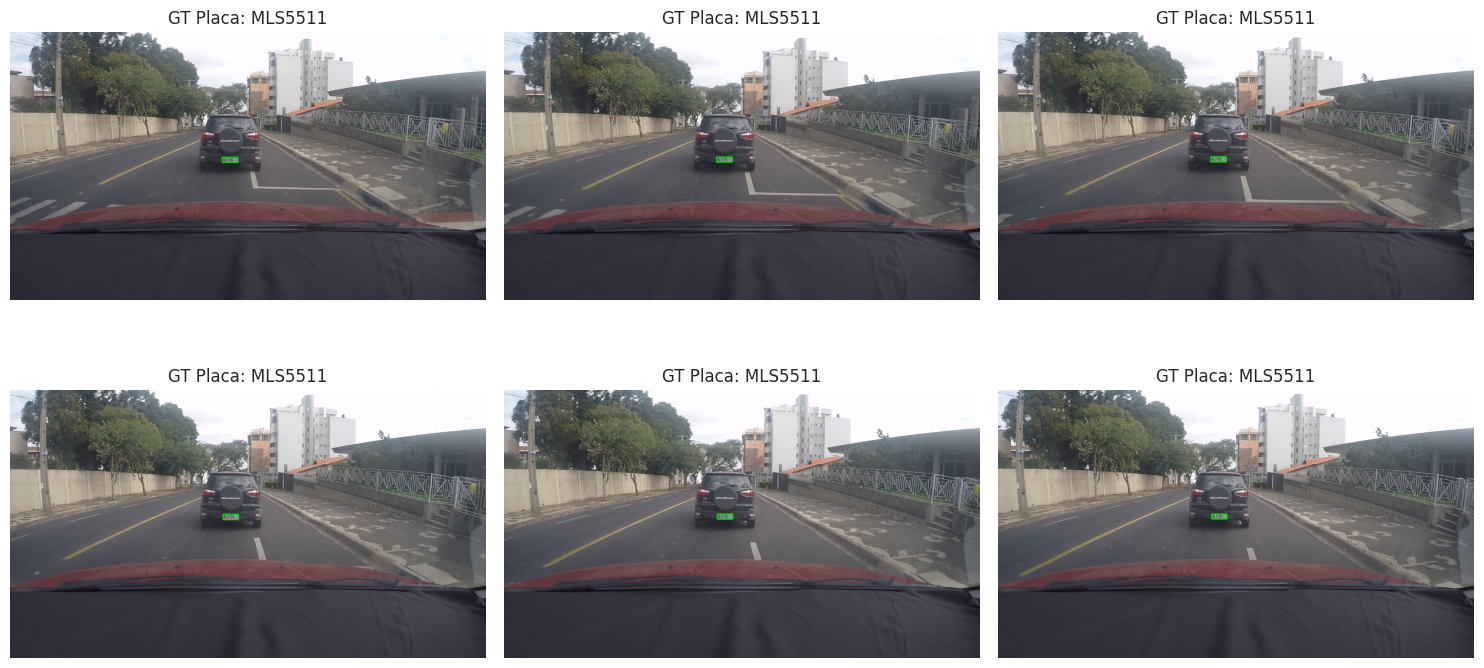

In [3]:

ufpr_samples = load_dataset_split(UFPR_ROOT, split="testing", limit=6)
print(f"Amostras carregadas para visualização: {len(ufpr_samples)}")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, s in zip(axes.flat, ufpr_samples):
    img = cv2.imread(str(s["image_path"])).copy()
    vis = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    b   = s["annotation"]["plate_bbox"]
    cv2.rectangle(vis, (b[0], b[1]), (b[2], b[3]), (0, 220, 0), 3)
    ax.imshow(vis); ax.axis("off")
    ax.set_title(f"GT Placa: {s['annotation']['plate_text']}")
plt.tight_layout()
plt.show()

## 3. Demonstração Visual do Pipeline ALPR (Estágio por Estágio)

Célula interativa para exibir visualmente cada etapa da pipeline: Detecção do veículo -> Recorte do veículo -> Detecção da Placa -> Pré-processamento digital -> Leitura OCR final.

Carregando modelo YOLOv8 para detecção de placas...


Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Número de placas encontradas: 1
{'bbox': [94.84561920166016, 175.88394165039062, 161.0298614501953, 201.80563354492188], 'conf': 0.9540398120880127, 'class': 'plate'}


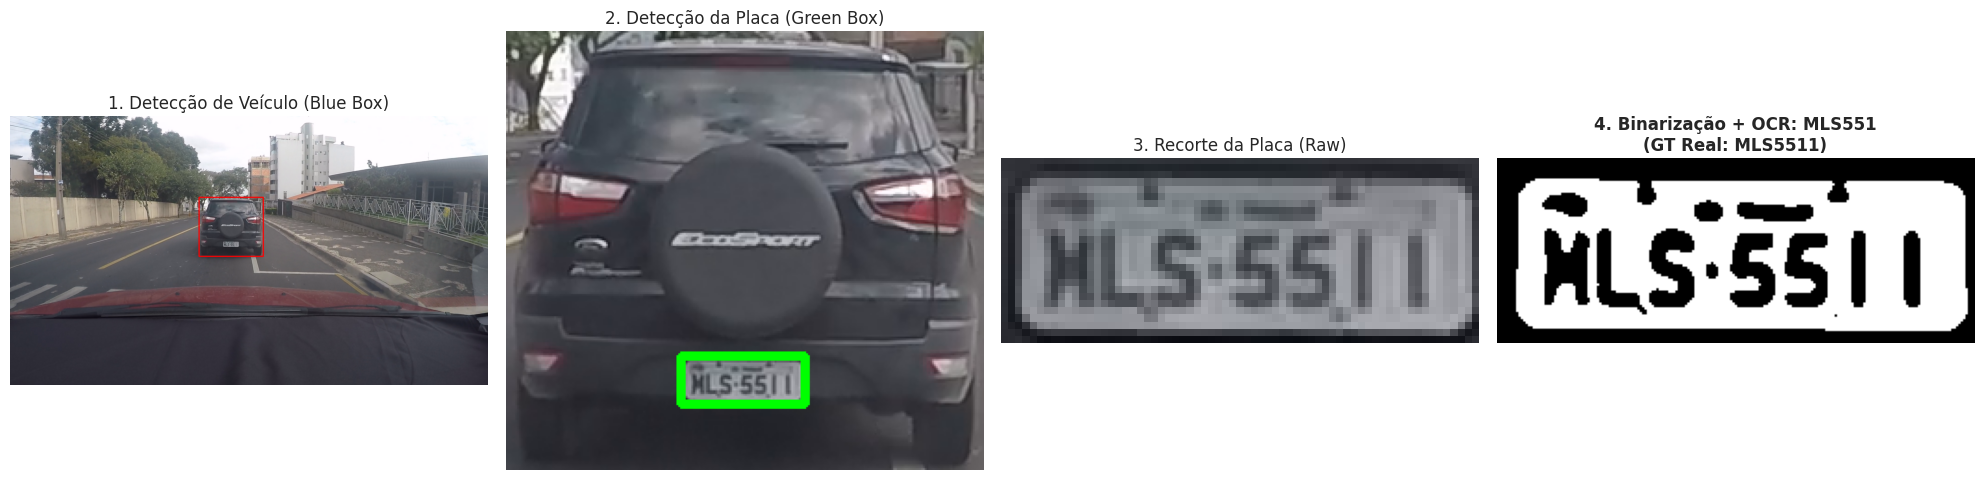

In [4]:

# Inicializa os modelos para demonstração
v_det = YOLODetector(str(BASE_DIR / "models" / "yolov8n.pt"))
p_det = PlateDetector()
ocr = OCREngine(engine_type="easyocr")

# Carrega uma amostra do dataset
sample = ufpr_samples[0]
img = cv2.imread(str(sample['image_path']))
h_img, w_img = img.shape[:2]

# Estágio 1: Detecção do Veículo
vehicles = v_det.detect(img)
vehicle_box = [0, 0, w_img, h_img]
for d in vehicles:
    if d['class'] in ['car', 'truck', 'bus', 'motorcycle']:
        vehicle_box = list(map(int, d['bbox']))
        break
vx1, vy1, vx2, vy2 = vehicle_box
veh_crop = img[vy1:vy2, vx1:vx2]

# Estágio 2: Detecção de Placa no Recorte
plates = p_det.detect(veh_crop)
print("Número de placas encontradas:", len(plates))

for p in plates:
    print(p)
plate_box = [0, 0, veh_crop.shape[1], veh_crop.shape[0]]
if plates:
    plate_box = list(map(int, plates[0]['bbox']))
px1, py1, px2, py2 = plate_box
plate_crop = veh_crop[py1:py2, px1:px2]

# Estágio 3: OCR e Binarização
plate_preprocessed = ocr.preprocess_plate(plate_crop)
plate_text = ocr.read_plate(plate_crop)

# Plotando a cascata do pipeline
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

vis_orig = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2.rectangle(vis_orig, (vx1, vy1), (vx2, vy2), (255, 0, 0), 4)
axes[0].imshow(vis_orig); axes[0].set_title("1. Detecção de Veículo (Blue Box)"); axes[0].axis("off")

vis_veh = cv2.cvtColor(veh_crop, cv2.COLOR_BGR2RGB)
cv2.rectangle(vis_veh, (px1, py1), (px2, py2), (0, 255, 0), 4)
axes[1].imshow(vis_veh); axes[1].set_title("2. Detecção da Placa (Green Box)"); axes[1].axis("off")

vis_plate = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB)
axes[2].imshow(vis_plate); axes[2].set_title("3. Recorte da Placa (Raw)"); axes[2].axis("off")

axes[3].imshow(plate_preprocessed, cmap="gray")
axes[3].set_title(f"4. Binarização + OCR: {plate_text}\n(GT Real: {sample['annotation']['plate_text']})", weight="bold")
axes[3].axis("off")

plt.tight_layout()
plt.show()

## 4. Execução do Benchmark ALPR Completo

  BENCHMARK ALPR — UFPR-ALPR (end_to_end)

Carregando split 'testing'...
  Total de amostras carregadas: 300
  Carregando YOLOv8... OK
  Carregando SSD... OK
  Carregando Faster R-CNN... 

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


OK

>>> Testando: YOLOv8


YOLOv8: 100%|██████████| 300/300 [01:11<00:00,  4.21it/s]



>>> Testando: SSD


SSD: 100%|██████████| 300/300 [01:25<00:00,  3.51it/s]



>>> Testando: Faster R-CNN


Faster R-CNN: 100%|██████████| 300/300 [13:30<00:00,  2.70s/it]



Resultados salvos em: /home/nicman/Desktop/TCC1/dataset_processado/resultados/alpr_benchmark_end_to_end.csv

  RELATÓRIO FINAL — UFPR-ALPR (end_to_end)
              Total_Frames Vehicle_Detected Plate_Found OCR_Executado  IoU_Medio  CER_Medio Acerto_Frame Acerto_Track_Voto
model                                                                                                                     
Faster R-CNN           300           100.0%       91.7%         91.7%     0.7322     0.4052        17.0%             20.0%
SSD                    300            59.3%       87.0%         87.0%     0.6995     0.4052        16.7%             20.0%
YOLOv8                 300           100.0%       89.7%         89.7%     0.7297     0.3986        18.7%             20.0%



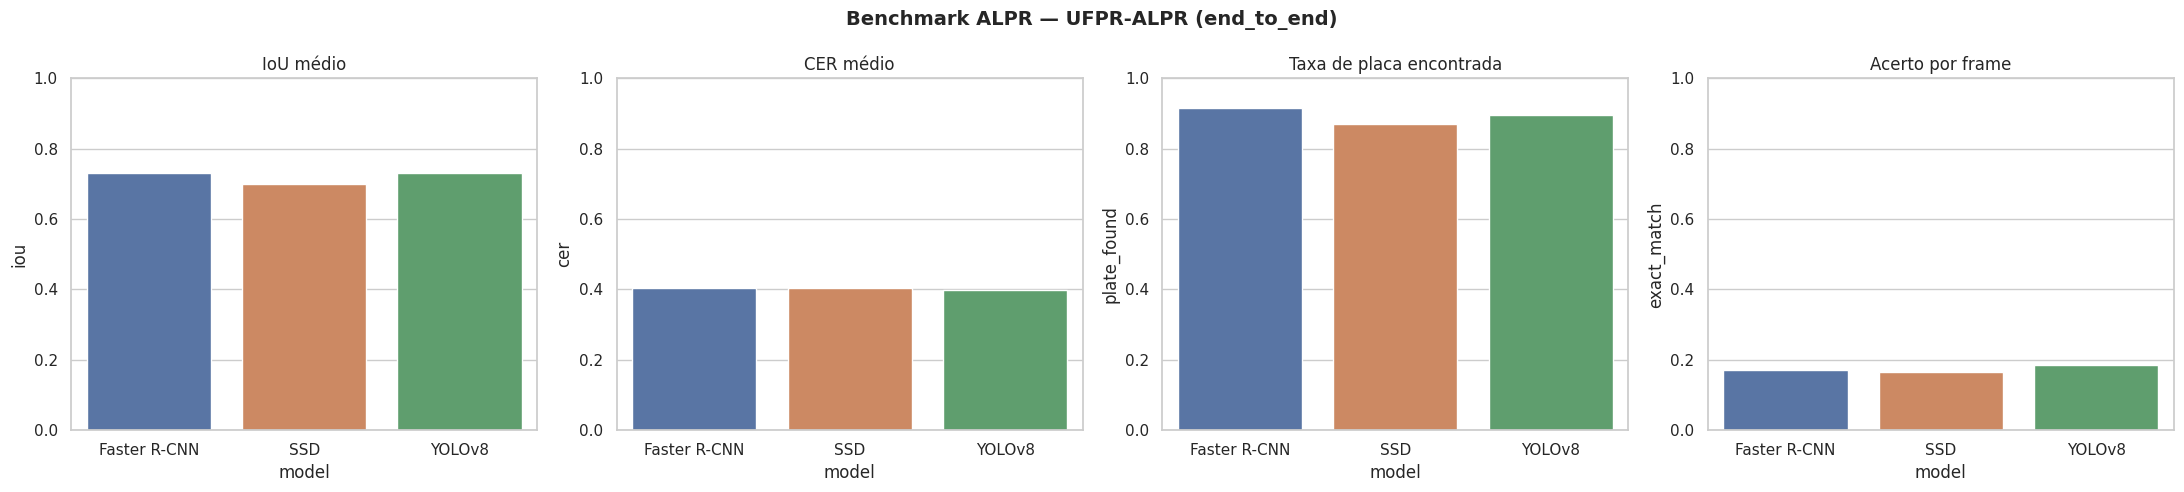

Gráficos salvos em: /home/nicman/Desktop/TCC1/dataset_processado/resultados/alpr_comparativo_end_to_end.png


,mode,model,track,image,gt_plate,pred_plate,vehicle_found,vehicle_iou,vehicle_bbox_source,plate_found,plate_bbox_source,ocr_executed,iou,cer,exact_match
0,end_to_end,YOLOv8,track0091,track0091[01].png,MLS5511,MLS551,True,0.9502,detected,True,detected,True,0.7678,0.1429,False
1,end_to_end,YOLOv8,track0091,track0091[02].png,MLS5511,NLS55,True,0.9452,detected,True,detected,True,0.7456,0.4286,False
2,end_to_end,YOLOv8,track0091,track0091[03].png,MLS5511,KLS55,True,0.9687,detected,True,detected,True,0.7651,0.4286,False
3,end_to_end,YOLOv8,track0091,track0091[04].png,MLS5511,KLS551,True,0.9692,detected,True,detected,True,0.8054,0.2857,False
4,end_to_end,YOLOv8,track0091,track0091[05].png,MLS5511,MLS55,True,0.9534,detected,True,detected,True,0.7697,0.2857,False


In [5]:
import run_alpr_benchmark as alpr_mod

df_alpr = alpr_mod.run_benchmark(
    split="testing",
    limit=300,
    mode="end_to_end"
)
display(df_alpr.head())

Iniciando execução do Benchmark ALPR Oracle (Limite de imagens: 1500)...
  BENCHMARK ALPR — UFPR-ALPR (ocr_oracle)

Carregando split 'testing'...
  Total de amostras carregadas: 1500
  Carregando YOLOv8... OK
  Carregando SSD... OK
  Carregando Faster R-CNN... 

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


OK

>>> Testando: YOLOv8


YOLOv8: 100%|██████████| 1500/1500 [05:36<00:00,  4.46it/s]



>>> Testando: SSD


SSD: 100%|██████████| 1500/1500 [06:03<00:00,  4.13it/s]



>>> Testando: Faster R-CNN


Faster R-CNN: 100%|██████████| 1500/1500 [1:10:24<00:00,  2.82s/it]



Resultados salvos em: /home/nicman/Desktop/TCC1/dataset_processado/resultados/alpr_benchmark_ocr_oracle.csv

  RELATÓRIO FINAL — UFPR-ALPR (ocr_oracle)
              Total_Frames Vehicle_Detected Plate_Found OCR_Executado  IoU_Medio  CER_Medio Acerto_Frame Acerto_Track_Voto
model                                                                                                                     
Faster R-CNN          1500            99.5%      100.0%         97.8%        1.0     0.3850        23.3%             30.0%
SSD                   1500            72.9%      100.0%         92.9%        1.0     0.4007        24.3%             30.0%
YOLOv8                1500           100.0%      100.0%         96.4%        1.0     0.3852        24.1%             30.0%



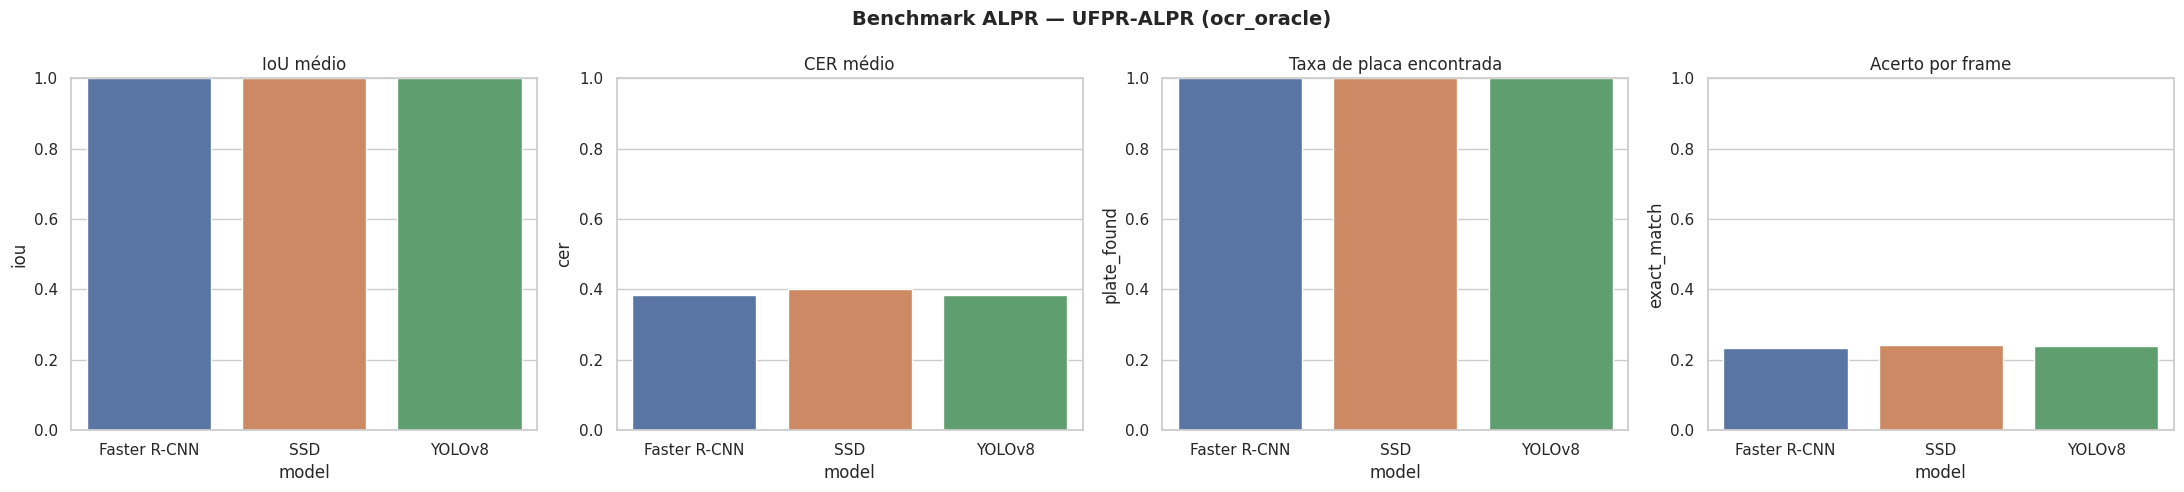

Gráficos salvos em: /home/nicman/Desktop/TCC1/dataset_processado/resultados/alpr_comparativo_ocr_oracle.png


,mode,model,track,image,gt_plate,pred_plate,vehicle_found,vehicle_iou,vehicle_bbox_source,plate_found,plate_bbox_source,ocr_executed,iou,cer,exact_match
0,ocr_oracle,YOLOv8,track0091,track0091[01].png,MLS5511,MLS551,True,0.9502,detected,True,gt_oracle,True,1.0,0.1429,False
1,ocr_oracle,YOLOv8,track0091,track0091[02].png,MLS5511,MLS551,True,0.9452,detected,True,gt_oracle,True,1.0,0.1429,False
2,ocr_oracle,YOLOv8,track0091,track0091[03].png,MLS5511,KLS551,True,0.9687,detected,True,gt_oracle,True,1.0,0.2857,False
3,ocr_oracle,YOLOv8,track0091,track0091[04].png,MLS5511,KLS551,True,0.9692,detected,True,gt_oracle,True,1.0,0.2857,False
4,ocr_oracle,YOLOv8,track0091,track0091[05].png,MLS5511,MLS55,True,0.9534,detected,True,gt_oracle,True,1.0,0.2857,False


In [6]:
print(f"Iniciando execução do Benchmark ALPR Oracle (Limite de imagens: {LIMIT})...")
df_oracle = alpr_mod.run_benchmark(
    split="testing",
    limit=LIMIT,
    mode="ocr_oracle"
)
display(df_oracle.head())

## 7. Ranking Comparativo Global (Cruzamento de Experimentos 1 e 2)

Esta seção unifica as métricas obtidas no **Experimento 1 (UA-DETRAC)** e no **Experimento 2 (UFPR-ALPR)** para gerar um score geral ponderado dos modelos (YOLOv8, SSD, Faster R-CNN) sob as seguintes métricas:
- **F1-Score (Detecção - UA-DETRAC)**: Peso 30%
- **Velocidade de Processamento (FPS - UA-DETRAC)**: Peso 20%
- **Precisão de Segmentação (IoU da Placa - UFPR-ALPR)**: Peso 20%
- **Acurácia do Texto (1 - CER - UFPR-ALPR)**: Peso 30%


RANKING COMPARATIVO GLOBAL - EXPERIMENTOS 1 E 2
 Posição    Algoritmo  F1 (Detecção)       FPS  IoU (Placa)  OCR (Acerto) Score Geral (Ponderado)
       1       YOLOv8       0.592326 16.101533     0.729733      0.601419                   96.2%
       2 Faster R-CNN       0.583492  0.593867     0.732192      0.594753                  49.35%
       3          SSD       0.186046 18.110933     0.699531      0.594752                   20.0%

CÓDIGO LATEX DO RANKING PARA A MONOGRAFIA
\begin{table}
\caption{Ranking comparativo global dos algoritmos cruzando detecção, velocidade e OCR}
\label{tab:ranking_global}
\begin{tabular}{rlrrrrl}
\toprule
Posição & Algoritmo & F1 (Detecção) & FPS & IoU (Placa) & OCR (Acerto) & Score Geral (Ponderado) \\
\midrule
1 & YOLOv8 & 0.592326 & 16.101533 & 0.729733 & 0.601419 & 96.2% \\
2 & Faster R-CNN & 0.583492 & 0.593867 & 0.732192 & 0.594753 & 49.35% \\
3 & SSD & 0.186046 & 18.110933 & 0.699531 & 0.594752 & 20.0% \\
\bottomrule
\end{tabular}
\end{table}



/tmp/ipykernel_7570/1392801904.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_ranking, x='model', y='Score_Geral', palette='coolwarm', edgecolor='black')


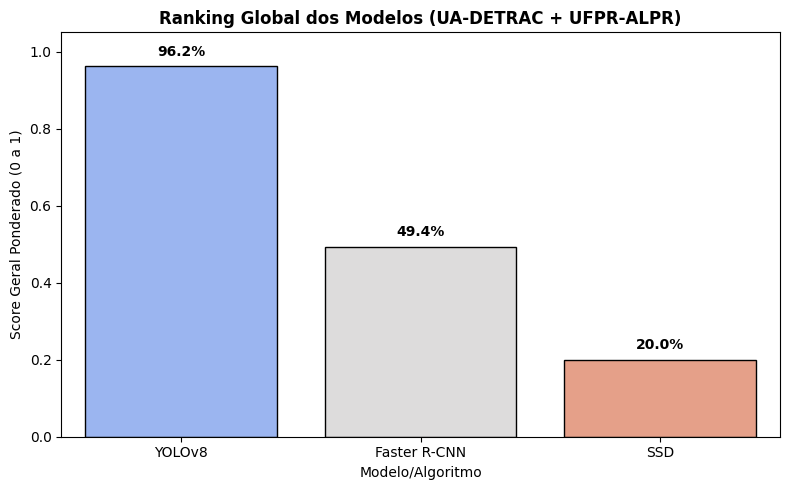

Gráfico do ranking salvo em: /home/nicman/Desktop/TCC1/dataset_processado/resultados/ranking_global_comparativo.png


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE_DIR = Path.cwd().parent
RESULTS_DIR = BASE_DIR / "data" / "processado" / "resultados"

ua_csv = RESULTS_DIR / "ua_detrac_benchmark.csv"
alpr_csv = RESULTS_DIR / "alpr_benchmark_end_to_end.csv"

if ua_csv.exists() and alpr_csv.exists():
    df_ua = pd.read_csv(ua_csv)
    df_alpr = pd.read_csv(alpr_csv)
    
    # 1. Agrupamento das métricas do Experimento 1 (UA-DETRAC)
    ua_summary = df_ua.groupby('model').agg(
        F1_Detecção=('f1', 'mean'),
        FPS_Detecção=('fps', 'mean')
    ).reset_index()
    
    # 2. Agrupamento das métricas do Experimento 2 (UFPR-ALPR)
    alpr_summary = df_alpr.groupby('model').agg(
        IoU_Placa=('iou', 'mean'),
        CER_OCR=('cer', 'mean'),
        Acuracia_Frame=('exact_match', 'mean')
    ).reset_index()
    
    # Cruzamento dos resultados
    df_ranking = pd.merge(ua_summary, alpr_summary, on='model')
    
    # Inverte o CER para ter uma métrica de acerto (quanto menor o CER, melhor o OCR)
    df_ranking['OCR_Acerto'] = 1.0 - df_ranking['CER_OCR']
    
    # 3. Normalização Min-Max para tornar as métricas comparáveis (0 a 1)
    metrics_to_normalize = ['F1_Detecção', 'FPS_Detecção', 'IoU_Placa', 'OCR_Acerto']
    for col in metrics_to_normalize:
        col_min = df_ranking[col].min()
        col_max = df_ranking[col].max()
        if col_max - col_min > 1e-5:
            df_ranking[f'{col}_norm'] = (df_ranking[col] - col_min) / (col_max - col_min)
        else:
            df_ranking[f'{col}_norm'] = 1.0
            
    # 4. Cálculo do Score Geral Ponderado
    pesos = {
        'F1_Detecção_norm': 0.30,
        'FPS_Detecção_norm': 0.20,
        'IoU_Placa_norm': 0.20,
        'OCR_Acerto_norm': 0.30
    }
    
    df_ranking['Score_Geral'] = 0.0
    for col, peso in pesos.items():
        df_ranking['Score_Geral'] += df_ranking[col] * peso
        
    # Ordena pelo Score Geral
    df_ranking = df_ranking.sort_values(by='Score_Geral', ascending=False).reset_index(drop=True)
    df_ranking['Posição'] = df_ranking.index + 1
    
    # Colunas para exibição amigável
    colunas_finais = ['Posição', 'model', 'F1_Detecção', 'FPS_Detecção', 'IoU_Placa', 'OCR_Acerto', 'Score_Geral']
    df_exibicao = df_ranking[colunas_finais].copy()
    df_exibicao['Score_Geral'] = (df_exibicao['Score_Geral'] * 100).round(2).astype(str) + '%'
    df_exibicao.columns = ['Posição', 'Algoritmo', 'F1 (Detecção)', 'FPS', 'IoU (Placa)', 'OCR (Acerto)', 'Score Geral (Ponderado)']
    
    print("\n" + "="*60)
    print("RANKING COMPARATIVO GLOBAL - EXPERIMENTOS 1 E 2")
    print("="*60)
    print(df_exibicao.to_string(index=False))
    
    # Gerando código LaTeX do Ranking
    print("\n" + "="*45)
    print("CÓDIGO LATEX DO RANKING PARA A MONOGRAFIA")
    print("="*45)
    print(df_exibicao.to_latex(index=False, caption="Ranking comparativo global dos algoritmos cruzando detecção, velocidade e OCR", label="tab:ranking_global"))
    
    # Plot do Ranking Geral
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(data=df_ranking, x='model', y='Score_Geral', palette='coolwarm', edgecolor='black')
    plt.title('Ranking Global dos Modelos (UA-DETRAC + UFPR-ALPR)', fontsize=12, fontweight='bold')
    plt.ylabel('Score Geral Ponderado (0 a 1)')
    plt.xlabel('Modelo/Algoritmo')
    plt.ylim(0, 1.05)
    
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height*100:.1f}%',
                    (p.get_x() + p.get_width() / 2., height + 0.02),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
                    
    plt.tight_layout()
    chart_path = RESULTS_DIR / 'ranking_global_comparativo.png'
    plt.savefig(chart_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Gráfico do ranking salvo em: {chart_path}")
else:
    print("Erro: Certifique-se de que os arquivos CSV de ambos os experimentos existem em 'dataset_processado/resultados'.")